### **Model Building**

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import os
import warnings
import joblib

In [7]:
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv("../data/processed/processed_sales_data.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Price,Discount,Weather Condition,Promotion,...,Epidemic,Demand,Day,Month,DayOfWeek,IsWeekend,Quarter,Demand_Lag_1,Demand_Lag_7,Demand_Rolling_Mean_7
0,2022-01-08,S001,P0001,Electronics,North,308,68.56,10,Snowy,1,...,0,113,8,1,5,1,1,87.0,115.0,105.571429
1,2022-01-08,S001,P0002,Clothing,North,77,76.30,15,Snowy,1,...,0,208,8,1,5,1,1,94.0,229.0,133.428571
2,2022-01-08,S001,P0003,Clothing,North,308,54.15,15,Snowy,1,...,0,142,8,1,5,1,1,71.0,157.0,120.000000
3,2022-01-08,S001,P0004,Electronics,North,155,69.37,20,Snowy,1,...,0,36,8,1,5,1,1,57.0,52.0,59.000000
4,2022-01-08,S001,P0005,Groceries,North,1293,53.57,5,Snowy,0,...,0,83,8,1,5,1,1,97.0,59.0,114.000000


In [9]:
df = df.sort_values(by=['Store ID', 'Product ID', 'Date']).reset_index(drop=True)

In [10]:
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

In [11]:
drop_cols = ['Demand', 'Date'] 
X_train, y_train = train_df.drop(columns=drop_cols), train_df['Demand']
X_test, y_test = test_df.drop(columns=drop_cols), test_df['Demand']

In [12]:
categorical_cols = ['Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']

preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

In [13]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMRegressor(random_state=42, n_jobs=-1))
])

In [14]:
tscv = TimeSeriesSplit(n_splits=3)

In [15]:
param_grid = {
    'model__n_estimators': [100, 200],         
    'model__learning_rate': [0.05, 0.1],      
    'model__max_depth': [5, 7, -1]           
}

In [16]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,              
    scoring='neg_mean_absolute_error',
    verbose=2,
    n_jobs=-1
)

In [17]:
print("🚀 เริ่มเทรนโมเดล...")
grid_search.fit(X_train, y_train)

print(f"✅ เทรนเสร็จสิ้น! พารามิเตอร์ที่ดีที่สุดคือ: {grid_search.best_params_}")

🚀 เริ่มเทรนโมเดล...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004672 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1681
[LightGBM] [Info] Number of data points in the train set: 60240, number of used features: 55
[LightGBM] [Info] Start training from score 103.882122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [18]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n📊 ผลการประเมินบน Test Set (20% หลังสุด):")
print(f"MAE (ทายพลาดเฉลี่ย): {mae:.2f} ชิ้น")
print(f"RMSE (ทายพลาดเฉลี่ยถ่วงน้ำหนัก): {rmse:.2f} ชิ้น")


📊 ผลการประเมินบน Test Set (20% หลังสุด):
MAE (ทายพลาดเฉลี่ย): 25.06 ชิ้น
RMSE (ทายพลาดเฉลี่ยถ่วงน้ำหนัก): 32.69 ชิ้น


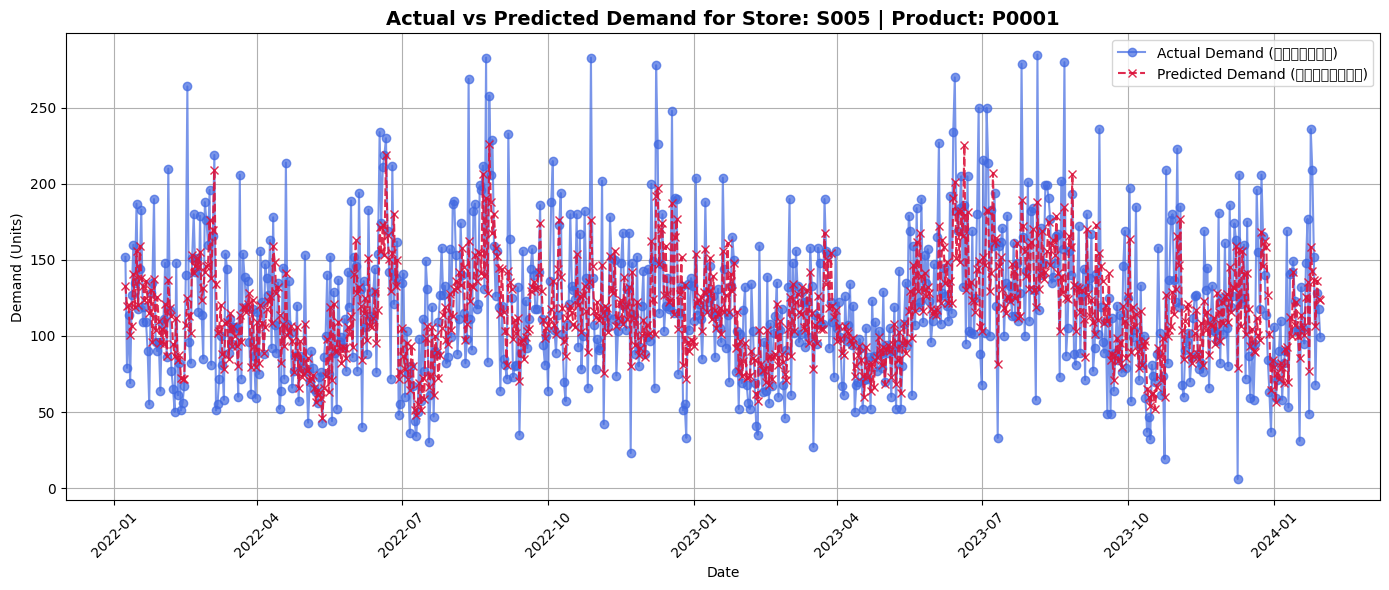

In [ ]:
df_results = X_test.copy()
df_results['Actual_Demand'] = y_test.values
df_results['Predicted_Demand'] = y_pred
df_results['Date'] = pd.to_datetime(test_df['Date'].values)

sample_store = df_results['Store ID'].iloc[0]
sample_product = df_results['Product ID'].iloc[0]

df_sample = df_results[(df_results['Store ID'] == sample_store) & 
                        (df_results['Product ID'] == sample_product)].sort_values('Date')

plt.figure(figsize=(14, 6))
plt.plot(df_sample['Date'], df_sample['Actual_Demand'], label='Actual Demand (ยอดจริง)', color='royalblue', marker='o', alpha=0.7)
plt.plot(df_sample['Date'], df_sample['Predicted_Demand'], label='Predicted Demand (โมเดลทาย)', color='crimson', linestyle='--', marker='x', alpha=0.9)

plt.title(f'Actual vs Predicted Demand for Store: {sample_store} | Product: {sample_product}', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand (Units)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Model Saving**

In [21]:
os.makedirs("../models", exist_ok=True)
model_path = "../models/best_lgbm_model.pkl"
joblib.dump(best_model, model_path)
print(f"✅ โมเดลถูกบันทึกที่: {model_path}")

✅ โมเดลถูกบันทึกที่: ../models/best_lgbm_model.pkl
